### Least Squares in Python

This notebook implements core building blocks for direct linear algebra methods,
including forward and backward substitution, and applies them to least squares problems.

## Objectives
- implement forward and backward substitution
- solve least squares problems via normal equations
- solve least squares problems via QR decomposition
- compare the numerical stability of both approaches

Validation of triangular solvers
Backward substitution
Computed solution : [-0.25  0.5   2.  ]
Reference solution: [-0.25  0.5   2.  ]
Max error         : 0.0

Forward substitution
Computed solution : [1. 2. 1.]
Reference solution: [1. 2. 1.]
Max error         : 5.551115123125783e-16

Validation of least squares solvers
Normal equations solution: [3.5 1.4]
QR solution              : [3.5 1.4]
NumPy lstsq solution     : [3.5 1.4]
Max error (normal vs ref): 4.440892098500626e-16
Max error (QR vs ref)    : 4.440892098500626e-16



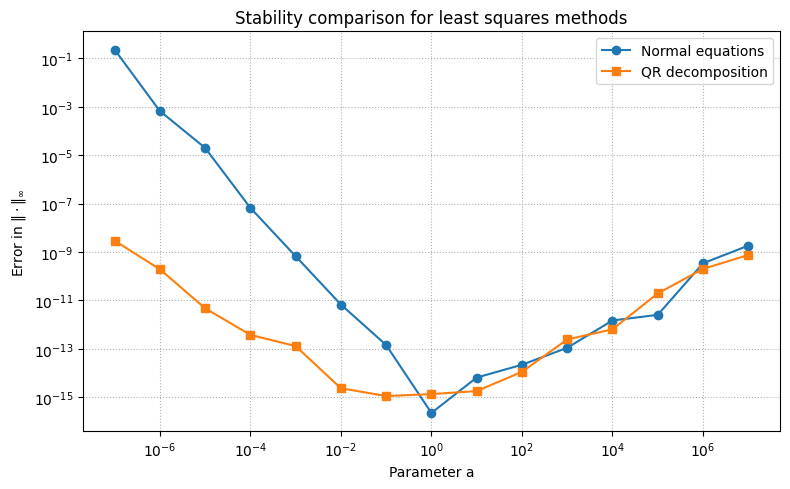

Conclusion
QR decomposition is typically more numerically stable than normal equations,
especially when the least squares problem becomes poorly conditioned.
Plot saved to: least_squares_stability.png


In [1]:
# ================================================
# Least Squares in Python
# Triangular Solvers, Normal Equations, and QR Decomposition
# ================================================

import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la


# ------------------------------------------------
# Triangular system solvers
# ------------------------------------------------
def backward_substitution(R, b):
    """
    Solve the upper triangular system Rx = b by backward substitution.
    """
    R = np.array(R, dtype=float)
    b = np.array(b, dtype=float)

    n = R.shape[0]

    if R.ndim != 2 or R.shape[0] != R.shape[1]:
        raise ValueError("R must be a square matrix.")
    if b.shape[0] != n:
        raise ValueError("Dimensions of R and b do not match.")

    x = np.zeros(n, dtype=float)

    for i in range(n - 1, -1, -1):
        if abs(R[i, i]) < 1e-15:
            raise ZeroDivisionError("Zero diagonal entry encountered in backward substitution.")
        x[i] = (b[i] - np.dot(R[i, i + 1:], x[i + 1:])) / R[i, i]

    return x


def forward_substitution(L, b):
    """
    Solve the lower triangular system Lx = b by forward substitution.
    """
    L = np.array(L, dtype=float)
    b = np.array(b, dtype=float)

    n = L.shape[0]

    if L.ndim != 2 or L.shape[0] != L.shape[1]:
        raise ValueError("L must be a square matrix.")
    if b.shape[0] != n:
        raise ValueError("Dimensions of L and b do not match.")

    x = np.zeros(n, dtype=float)

    for i in range(n):
        if abs(L[i, i]) < 1e-15:
            raise ZeroDivisionError("Zero diagonal entry encountered in forward substitution.")
        x[i] = (b[i] - np.dot(L[i, :i], x[:i])) / L[i, i]

    return x


# ------------------------------------------------
# Least squares solvers
# ------------------------------------------------
def solve_normal_equations(A, b):
    """
    Solve the least squares problem min ||Ax - b||_2
    using the normal equations and a Cholesky factorization.
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)

    m, n = A.shape

    if b.shape[0] != m:
        raise ValueError("Dimensions of A and b do not match.")
    if m < n:
        raise ValueError("The system must satisfy m >= n.")

    AtA = A.T @ A
    Atb = A.T @ b

    L = la.cholesky(AtA, lower=True)
    y = forward_substitution(L, Atb)
    x = backward_substitution(L.T, y)

    return x


def solve_least_squares_qr(A, b):
    """
    Solve the least squares problem min ||Ax - b||_2
    using an economic QR decomposition.
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)

    m, n = A.shape

    if b.shape[0] != m:
        raise ValueError("Dimensions of A and b do not match.")
    if m < n:
        raise ValueError("The system must satisfy m >= n.")

    Q, R = la.qr(A, mode="economic")
    rhs = Q.T @ b
    x = backward_substitution(R, rhs)

    return x


# ------------------------------------------------
# Validation examples
# ------------------------------------------------
def validate_triangular_solvers():
    """
    Run simple validation examples for forward and backward substitution.
    """
    print("Validation of triangular solvers")

    R = np.array([
        [2.0, -1.0, 3.0],
        [0.0, 4.0, 2.0],
        [0.0, 0.0, 5.0]
    ])
    b1 = np.array([5.0, 6.0, 10.0])

    x_back = backward_substitution(R, b1)
    x_back_ref = np.linalg.solve(R, b1)

    print("Backward substitution")
    print("Computed solution :", x_back)
    print("Reference solution:", x_back_ref)
    print("Max error         :", np.max(np.abs(x_back - x_back_ref)))
    print()

    L = np.array([
        [2.0, 0.0, 0.0],
        [1.0, 3.0, 0.0],
        [4.0, -2.0, 1.0]
    ])
    b2 = np.array([2.0, 7.0, 1.0])

    x_forw = forward_substitution(L, b2)
    x_forw_ref = np.linalg.solve(L, b2)

    print("Forward substitution")
    print("Computed solution :", x_forw)
    print("Reference solution:", x_forw_ref)
    print("Max error         :", np.max(np.abs(x_forw - x_forw_ref)))
    print()


def validate_least_squares_solvers():
    """
    Compare least squares solvers on a small example.
    """
    print("Validation of least squares solvers")

    A = np.array([
        [1.0, 1.0],
        [1.0, 2.0],
        [1.0, 3.0],
        [1.0, 4.0]
    ])
    b = np.array([6.0, 5.0, 7.0, 10.0])

    x_normal = solve_normal_equations(A, b)
    x_qr = solve_least_squares_qr(A, b)
    x_ref, *_ = np.linalg.lstsq(A, b, rcond=None)

    print("Normal equations solution:", x_normal)
    print("QR solution              :", x_qr)
    print("NumPy lstsq solution     :", x_ref)
    print("Max error (normal vs ref):", np.max(np.abs(x_normal - x_ref)))
    print("Max error (QR vs ref)    :", np.max(np.abs(x_qr - x_ref)))
    print()


# ------------------------------------------------
# Stability experiment
# ------------------------------------------------
def compare_least_squares_stability():
    """
    Compare the numerical stability of normal equations and QR decomposition
    for a nearly ill-conditioned least squares problem.

    The exact solution is x* = [1, 1]^T and the parameter a varies over
    powers of ten from 10^-7 to 10^7.
    """
    x_exact = np.array([1.0, 1.0])

    exponents = np.arange(-7, 8)
    a_values = 10.0 ** exponents

    errors_normal = []
    errors_qr = []

    for a in a_values:
        A = np.array([
            [1.0, 1.0],
            [1.0, 1.0 + a],
            [1.0, 1.0 + a]
        ])
        b = np.array([2.0, 2.0 + a, 2.0 + a])

        x_normal = solve_normal_equations(A, b)
        x_qr = solve_least_squares_qr(A, b)

        errors_normal.append(np.linalg.norm(x_normal - x_exact, ord=np.inf))
        errors_qr.append(np.linalg.norm(x_qr - x_exact, ord=np.inf))

    errors_normal = np.array(errors_normal)
    errors_qr = np.array(errors_qr)

    plt.figure(figsize=(8, 5))
    plt.loglog(a_values, errors_normal, "o-", label="Normal equations")
    plt.loglog(a_values, errors_qr, "s-", label="QR decomposition")
    plt.xlabel("Parameter a")
    plt.ylabel(r"Error in $\|\cdot\|_\infty$")
    plt.title("Stability comparison for least squares methods")
    plt.grid(True, which="both", linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return a_values, errors_normal, errors_qr


# ------------------------------------------------
# Save plot for later download / GitHub
# ------------------------------------------------
def save_stability_plot(a_values, errors_normal, errors_qr,
                        filename="least_squares_stability.png"):
    """
    Save the stability comparison plot to an image file.
    """
    plt.figure(figsize=(8, 5))
    plt.loglog(a_values, errors_normal, "o-", label="Normal equations")
    plt.loglog(a_values, errors_qr, "s-", label="QR decomposition")
    plt.xlabel("Parameter a")
    plt.ylabel(r"Error in $\|\cdot\|_\infty$")
    plt.title("Stability comparison for least squares methods")
    plt.grid(True, which="both", linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Plot saved to: {filename}")


# ------------------------------------------------
# Example execution in notebook
# ------------------------------------------------
validate_triangular_solvers()
validate_least_squares_solvers()

a_values, errors_normal, errors_qr = compare_least_squares_stability()

print("Conclusion")
print("QR decomposition is typically more numerically stable than normal equations,")
print("especially when the least squares problem becomes poorly conditioned.")

# Save PNG for later download
save_stability_plot(a_values, errors_normal, errors_qr,
                    filename="least_squares_stability.png")

## Conclusion

The experiments show that both methods can solve least squares problems,
but QR decomposition is generally more numerically stable than the normal equations.
This is especially important for nearly ill-conditioned problems, where forming
the matrix \(A^T A\) can amplify numerical errors.